In [ ]:
import jax

jax.config.update("jax_enable_x64", True)

import zodiax as zdx
from jax import numpy as np, scipy as jsp, random as jr


class Gaussian(zdx.Base):
    mu: jax.Array
    logstdev: jax.Array

    def __init__(self, mu, stdev):
        self.mu = np.array(mu)
        self.logstdev = np.log10(stdev)

    @property
    def stdev(self):
        return 10**self.logstdev

    def model(self, x):
        return jsp.stats.norm.pdf(x, loc=self.mu, scale=self.stdev)

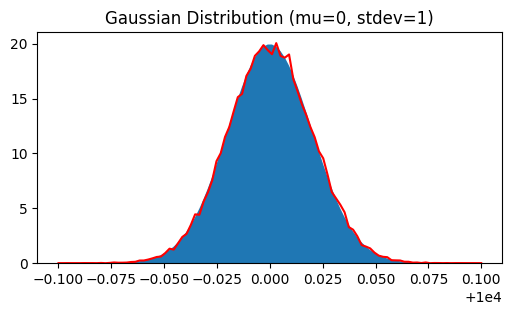

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

true_params = {"mu": 1e4, "stdev": 2e-2}
true_model = Gaussian(**true_params)

xs = true_params["mu"] + np.linspace(-0.1, 0.1, 100)
ys = true_model.model(xs)
data = ys + 0.1 * np.sqrt(ys) * jr.normal(jr.PRNGKey(0), ys.shape)

plt.figure(figsize=(6, 3))
plt.fill_between(xs, ys)
plt.plot(xs, data, color="red")
plt.ylim(0, None)
plt.title("Gaussian Distribution (mu=0, stdev=1)")
plt.show()

# Without Fisher pre-conditioning

In [ ]:
from zodiax.optimisation import sgd

# Now lets construct a loss function
opt_parameters = [
    "mu",
    "logstdev",
]
optimisers = {
    "mu": sgd(1e-8, 0),
    "logstdev": sgd(2e-6, 0),
}

init_guess = {"mu": 1.000001e4, "stdev": 4e-2}


@zdx.filter_jit
def likelihood(model, data):
    return np.square(model.model(xs) - data).sum()


@zdx.filter_jit
@zdx.filter_value_and_grad(opt_parameters)
def loss_fn(model, data):
    return likelihood(model, data)


# Evaluate loss function once Compile to XLA
init_model = Gaussian(**init_guess)
loss, grads = loss_fn(init_model, data)

# Get optax objcets
optimiser, state = zdx.get_optimiser(
    init_model, list(optimisers.keys()), list(optimisers.values())
)

losses = []
models = []
model = init_model
for i in range(30):
    loss, grads = loss_fn(model, data)
    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)

    losses.append(loss)
    models.append(model)

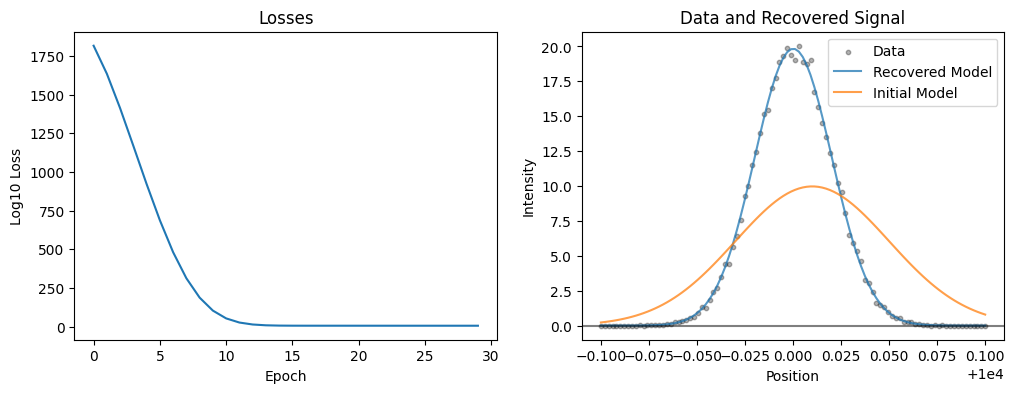

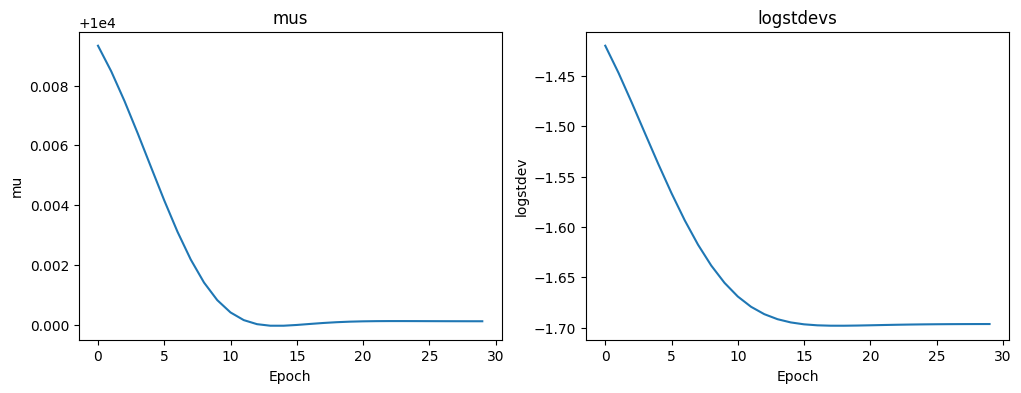

In [4]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.array(losses))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label="Data", color="k", alpha=0.3)
plt.plot(xs, model.model(xs), alpha=0.75, label="Recovered Model")
plt.plot(xs, init_model.model(xs), alpha=0.75, label="Initial Model")
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()


# parameter curves
mus = [m.mu for m in models]
logstdevs = [m.logstdev for m in models]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mus)
plt.title("mus")
plt.xlabel("Epoch")
plt.ylabel("mu")

plt.subplot(1, 2, 2)
plt.plot(logstdevs)
plt.title("logstdevs")
plt.xlabel("Epoch")
plt.ylabel("logstdev")
plt.show()

In [ ]:
n_pts = 100
test_mus = true_params["mu"] + np.linspace(-0.001, 0.001, n_pts)
test_logstdevs = true_model.logstdev + np.linspace(-0.05, 0.05, n_pts)

MU, LOGSTD = np.meshgrid(test_mus, test_logstdevs)


# Define a single-point log-likelihood function
def eval_loglike(mu, logstd):
    m = model.set(["mu", "logstdev"], [mu, logstd])
    return likelihood(m, data)


# Fully vectorised evaluation using jax.vmap over both axes
loglike_grid = jax.vmap(
    lambda logstd_row: jax.vmap(lambda mu: eval_loglike(mu, logstd_row))(test_mus)
)(test_logstdevs)
likelihood_grid = np.exp(-0.5 * loglike_grid)

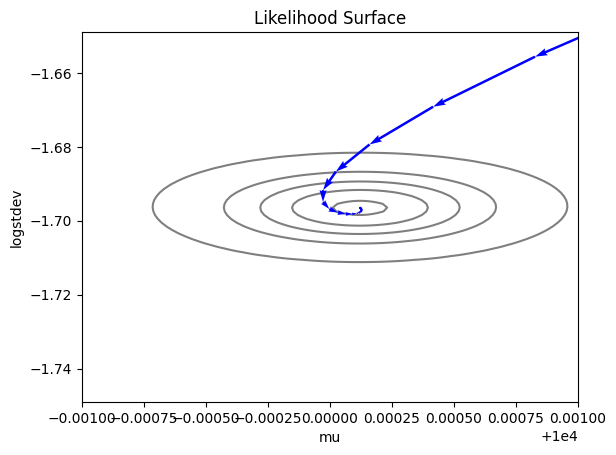

In [6]:
# Plot
fig, ax = plt.subplots()
gamma = 1
levels = (np.linspace(0.05, 0.95, 5) ** gamma) * np.max(likelihood_grid)
im = ax.contour(
    MU, LOGSTD, likelihood_grid, levels=levels, zorder=-10, colors="k", alpha=0.5
)
# ax.axvline(true_params["mu"], c="red", alpha=0.1, linestyle="dashed", zorder=-100)
# ax.axhline(true_model.logstdev, c="red", alpha=0.1, linestyle="dashed", zorder=-100)

mus = [m.mu for m in models]
logstdevs = [m.logstdev for m in models]
mus_arr = np.array(mus)
logstdevs_arr = np.array(logstdevs)


# ax.scatter(mus_arr, logstdevs_arr, s=20, color="k", zorder=5)
ax.quiver(
    mus_arr[:-1],
    logstdevs_arr[:-1],
    mus_arr[1:] - mus_arr[:-1],
    logstdevs_arr[1:] - logstdevs_arr[:-1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.005,
    color="blue",
    zorder=6,
)

ax.set(
    xlabel="mu",
    ylabel="logstdev",
    title="Likelihood Surface",
    xlim=(test_mus.min(), test_mus.max()),
    ylim=(test_logstdevs.min(), test_logstdevs.max()),
)
# ax.legend()
# fig.colorbar(im)
plt.show()

# With Fisher pre-conditioning

In [ ]:
fish = -zdx.fisher.covariance_matrix(true_model, opt_parameters, likelihood, data)

In [24]:
optimisers = {
    "mu": sgd(5e-1, 0),
    "logstdev": sgd(5e-1, 0),
}

init_guess = {
    "mu": 1.000001e4,
    "stdev": 4e-2,
}

# Evaluate loss function once Compile to XLA
init_model = Gaussian(**init_guess)
loss, grads = loss_fn(init_model, data)

# Get optax objcets
optimiser, state = zdx.get_optimiser(
    init_model, list(optimisers.keys()), list(optimisers.values())
)

losses = []
models = []
model = init_model
for i in range(30):
    loss, grads = loss_fn(model, data)

    ################# PRE-FISHER CONDITIONING #################
    gs = np.array([grads.mu, grads.logstdev])
    gs = fish @ gs
    grads = grads.set(["mu", "logstdev"], [gs[0], gs[1]])
    ###########################################################

    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)

    losses.append(loss)
    models.append(model)

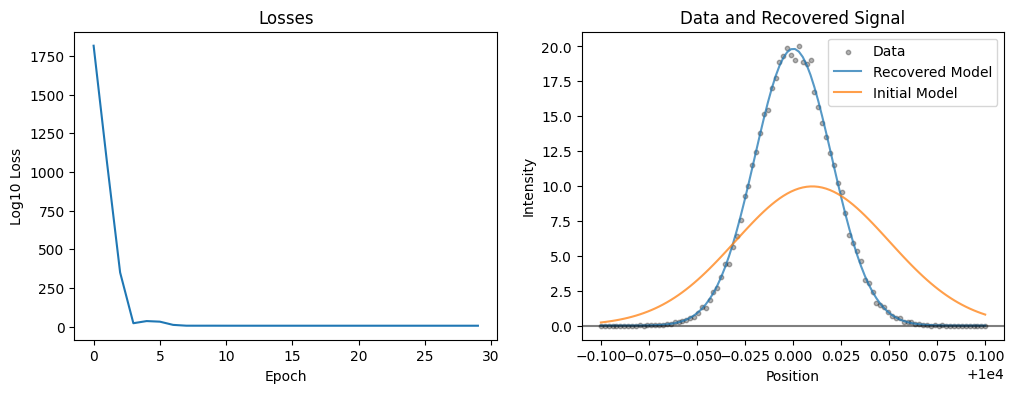

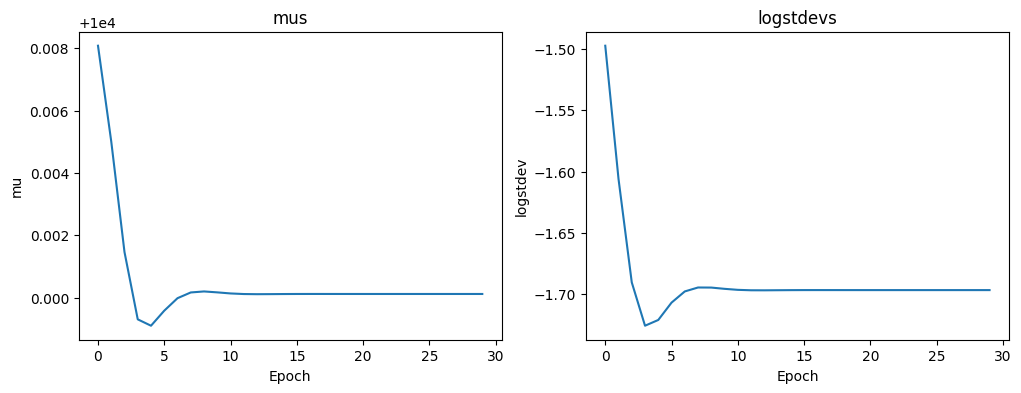

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.array(losses))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label="Data", color="k", alpha=0.3)
plt.plot(xs, model.model(xs), alpha=0.75, label="Recovered Model")
plt.plot(xs, init_model.model(xs), alpha=0.75, label="Initial Model")
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()


# parameter curves
mus = [m.mu for m in models]
logstdevs = [m.logstdev for m in models]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mus)
plt.title("mus")
plt.xlabel("Epoch")
plt.ylabel("mu")

plt.subplot(1, 2, 2)
plt.plot(logstdevs)
plt.title("logstdevs")
plt.xlabel("Epoch")
plt.ylabel("logstdev")
plt.show()

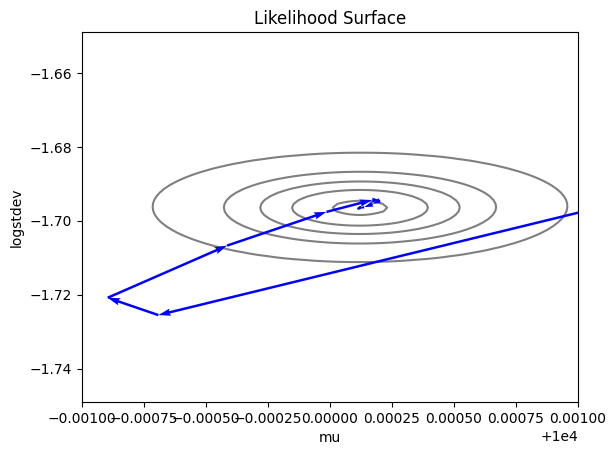

In [23]:
# Plot
fig, ax = plt.subplots()
gamma = 1
levels = (np.linspace(0.05, 0.95, 5) ** gamma) * np.max(likelihood_grid)
im = ax.contour(
    MU, LOGSTD, likelihood_grid, levels=levels, zorder=-10, colors="k", alpha=0.5
)
# ax.axvline(true_params["mu"], c="red", alpha=0.1, linestyle="dashed", zorder=-100)
# ax.axhline(true_model.logstdev, c="red", alpha=0.1, linestyle="dashed", zorder=-100)

mus = [m.mu for m in models]
logstdevs = [m.logstdev for m in models]
mus_arr = np.array(mus)
logstdevs_arr = np.array(logstdevs)


# ax.scatter(mus_arr, logstdevs_arr, s=20, color="k", zorder=5)
ax.quiver(
    mus_arr[:-1],
    logstdevs_arr[:-1],
    mus_arr[1:] - mus_arr[:-1],
    logstdevs_arr[1:] - logstdevs_arr[:-1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.005,
    color="blue",
    zorder=6,
)

ax.set(
    xlabel="mu",
    ylabel="logstdev",
    title="Likelihood Surface",
    xlim=(test_mus.min(), test_mus.max()),
    ylim=(test_logstdevs.min(), test_logstdevs.max()),
)
# ax.legend()
# fig.colorbar(im)
plt.show()